# NCAA Tournament Upset Analysis (2010–2025)

**Definitions:**
- **Lower seed** = higher seed number (e.g. seed 12 is *lower* than seed 5)
- **Upset** = lower-seeded team wins **AND** the seed difference is ≥ 5
- **Any underdog win** = lower-seeded team wins (any margin)

Covers both Men's and Women's NCAA tournaments.

In [8]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': '#0d1117',
                     'axes.facecolor': '#161b22', 'axes.edgecolor': '#30363d',
                     'axes.labelcolor': '#c9d1d9', 'text.color': '#c9d1d9',
                     'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
                     'grid.color': '#21262d', 'legend.facecolor': '#161b22',
                     'legend.edgecolor': '#30363d'})

## Load data

`final_features.csv` and `final_features_W.csv` already have `W_SEED` / `L_SEED` joined in.
The winner is always the W team (W_SCORE > L_SCORE by construction).

In [9]:
COLS = ['SEASON', 'ROUND', 'W_SEED', 'L_SEED', 'W_REGION']

men   = pd.read_csv('data_2026/final_features.csv', usecols=COLS)
women = pd.read_csv('data_2026/final_features_W.csv', usecols=COLS)

men['gender']   = 'Men'
women['gender'] = 'Women'

df = pd.concat([men, women], ignore_index=True)
df = df[df.SEASON >= 2010].copy()

# Derived columns
df['seed_diff']       = (df.W_SEED - df.L_SEED).abs()          # absolute seed gap
df['lower_seed_won']  = df.W_SEED > df.L_SEED                  # higher number = lower seed won
df['is_upset']        = (df.seed_diff >= 5) & df.lower_seed_won # upset definition
df['upset_eligible']  = df.seed_diff >= 5                       # matchups where upset possible

ROUND_NAMES = {0: 'Play-In', 1: 'R64', 2: 'R32', 3: 'S16', 4: 'E8', 5: 'FF', 6: 'Champ'}
df['round_name'] = df.ROUND.map(ROUND_NAMES)

print(f"Total games (2010–2025): {len(df):,}")
print(f"  Men's:   {(df.gender=='Men').sum():,}")
print(f"  Women's: {(df.gender=='Women').sum():,}")
df.head(3)

Total games (2010–2025): 1,897
  Men's:   988
  Women's: 909


,SEASON,ROUND,W_REGION,W_SEED,L_SEED,gender,seed_diff,lower_seed_won,is_upset,upset_eligible,round_name
448,2010,0,X,16,16,Men,0,False,False,False,Play-In
449,2010,1,X,3,14,Men,11,False,False,True,R64
450,2010,1,Z,5,12,Men,7,False,False,True,R64


## Top-level numbers

In [10]:
total   = len(df)
upsets  = df.is_upset.sum()
lower_w = df.lower_seed_won.sum()
elig    = df.upset_eligible.sum()

print("=" * 55)
print(f"  Total games played (2010–2025):          {total:>6,}")
print("=" * 55)
print(f"  Upsets (seed diff ≥5 & lower seed wins): {upsets:>6,}  ({upsets/total*100:.1f}% of all games)")
print(f"  Upset-eligible matchups (seed diff ≥5):  {elig:>6,}  ({elig/total*100:.1f}% of all games)")
print(f"  Of eligible games, upsets occurred:       {upsets:>5,}  ({upsets/elig*100:.1f}% of eligible games)")
print("-" * 55)
print(f"  Any underdog win (lower seed # wins):    {lower_w:>6,}  ({lower_w/total*100:.1f}% of all games)")
print("=" * 55)

  Total games played (2010–2025):           1,897
  Upsets (seed diff ≥5 & lower seed wins):    204  (10.8% of all games)
  Upset-eligible matchups (seed diff ≥5):   1,096  (57.8% of all games)
  Of eligible games, upsets occurred:         204  (18.6% of eligible games)
-------------------------------------------------------
  Any underdog win (lower seed # wins):       468  (24.7% of all games)


## By gender

In [11]:
g = df.groupby('gender').agg(
    total_games=('is_upset','count'),
    upsets=('is_upset','sum'),
    eligible=('upset_eligible','sum'),
    any_underdog=('lower_seed_won','sum'),
).assign(
    upset_pct_all=lambda x: x.upsets/x.total_games*100,
    upset_pct_eligible=lambda x: x.upsets/x.eligible*100,
    underdog_pct=lambda x: x.any_underdog/x.total_games*100,
)
print(g[['total_games','upsets','upset_pct_all','eligible','upset_pct_eligible','underdog_pct']].to_string())

        total_games  upsets  upset_pct_all  eligible  upset_pct_eligible  underdog_pct
gender                                                                                
Men             988     143      14.473684       583           24.528302     27.631579
Women           909      61       6.710671       513           11.890838     21.452145


## By round

In [12]:
round_order = ['Play-In', 'R64', 'R32', 'S16', 'E8', 'FF', 'Champ']

r = df.groupby('round_name').agg(
    total_games=('is_upset','count'),
    upsets=('is_upset','sum'),
    eligible=('upset_eligible','sum'),
    any_underdog=('lower_seed_won','sum'),
).assign(
    upset_pct_all=lambda x: x.upsets/x.total_games*100,
    upset_pct_eligible=lambda x: x.upsets/x.eligible.replace(0,np.nan)*100,
    underdog_pct=lambda x: x.any_underdog/x.total_games*100,
).reindex(round_order).dropna(how='all')

display(r[['total_games','upsets','upset_pct_all','eligible','upset_pct_eligible','underdog_pct']]
        .rename(columns={'total_games':'Games','upsets':'Upsets','upset_pct_all':'Upset% (all)',
                         'eligible':'Eligible','upset_pct_eligible':'Upset% (eligible)',
                         'underdog_pct':'Underdog%'})
        .style.format({'Upset% (all)':'{:.1f}%','Upset% (eligible)':'{:.1f}%','Underdog%':'{:.1f}%'})
        .background_gradient(subset=['Upset% (all)','Underdog%'], cmap='YlOrRd'))

,Games,Upsets,Upset% (all),Eligible,Upset% (eligible),Underdog%
round_name,,,,,,
Play-In,69,0,0.0%,0,nan%,0.0%
R64,827,103,12.5%,615,16.7%,23.5%
R32,530,75,14.2%,373,20.1%,24.3%
S16,199,8,4.0%,33,24.2%,30.7%
E8,94,3,3.2%,15,20.0%,35.1%
FF,40,3,7.5%,9,33.3%,20.0%
Champ,138,12,8.7%,51,23.5%,31.2%


## Upset % by seed matchup (R64 only)

Classic bracket: 1v16, 2v15, 3v14, 4v13, 5v12, 6v11, 7v10, 8v9

In [13]:
r64 = df[df.ROUND == 1].copy()

# Canonical matchup: lower seed number first
r64['fav_seed'] = r64[['W_SEED','L_SEED']].min(axis=1)
r64['dog_seed'] = r64[['W_SEED','L_SEED']].max(axis=1)
r64['matchup']  = r64.fav_seed.astype(str) + ' vs ' + r64.dog_seed.astype(str)

mu = r64.groupby('matchup').agg(
    games=('lower_seed_won','count'),
    upsets=('lower_seed_won','sum'),
).assign(upset_pct=lambda x: x.upsets/x.games*100).sort_values('upset_pct', ascending=False)

display(mu.style.format({'upset_pct':'{:.1f}%'})
        .background_gradient(subset=['upset_pct'], cmap='YlOrRd'))

,games,upsets,upset_pct
matchup,,,
8 vs 9,102,49,48.0%
6 vs 11,102,43,42.2%
7 vs 10,106,42,39.6%
5 vs 12,105,33,31.4%
4 vs 13,105,11,10.5%
3 vs 14,102,7,6.9%
2 vs 15,106,7,6.6%
1 vs 16,95,2,2.1%
11 vs 11,2,0,0.0%


## Upset rate by season (trend)

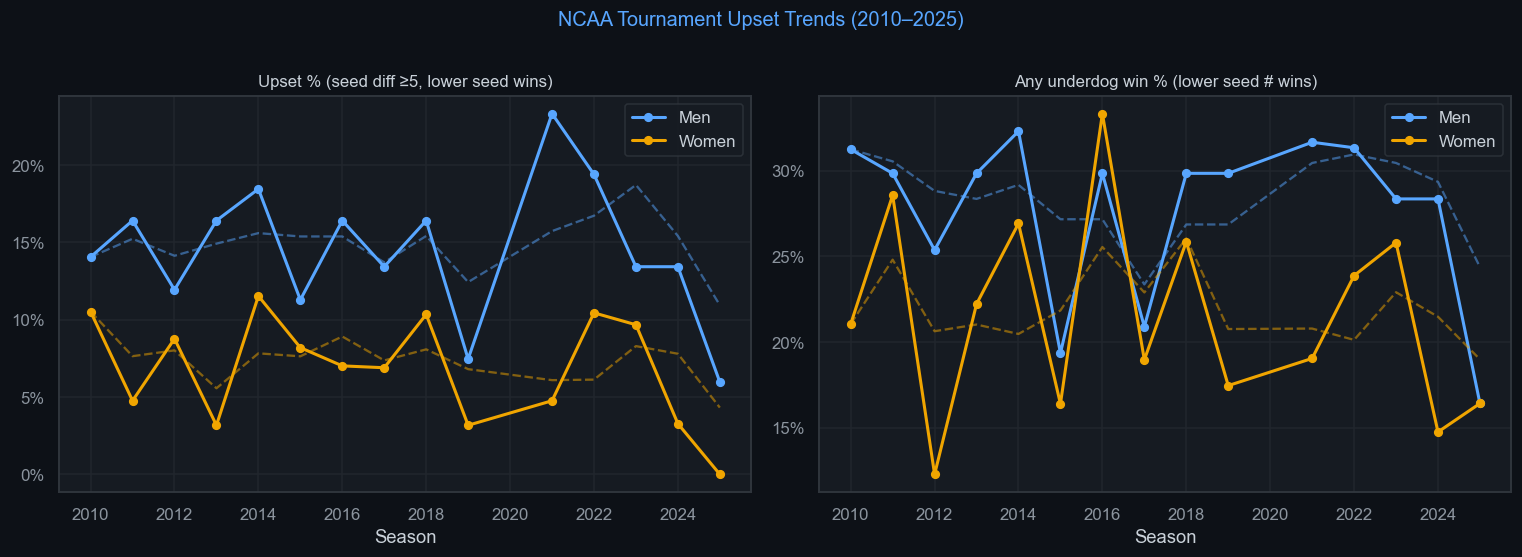

In [14]:
by_year = df.groupby(['SEASON','gender']).agg(
    total=('is_upset','count'),
    upsets=('is_upset','sum'),
    underdog=('lower_seed_won','sum'),
).assign(
    upset_pct=lambda x: x.upsets/x.total*100,
    underdog_pct=lambda x: x.underdog/x.total*100,
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

for ax, col, title, clr_m, clr_w in [
    (axes[0], 'upset_pct',    'Upset % (seed diff ≥5, lower seed wins)', '#58a6ff', '#f0a500'),
    (axes[1], 'underdog_pct', 'Any underdog win % (lower seed # wins)',  '#58a6ff', '#f0a500'),
]:
    for gender, clr in [('Men', clr_m), ('Women', clr_w)]:
        sub = by_year[by_year.gender == gender].sort_values('SEASON')
        ax.plot(sub.SEASON, sub[col], marker='o', label=gender, color=clr, linewidth=2, markersize=5)
        # rolling 3-yr avg
        ax.plot(sub.SEASON, sub[col].rolling(3, min_periods=1).mean(),
                linestyle='--', color=clr, alpha=0.5, linewidth=1.5)
    ax.set_title(title, color='#c9d1d9', fontsize=11)
    ax.set_xlabel('Season'); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.legend(); ax.set_facecolor('#161b22')

fig.suptitle('NCAA Tournament Upset Trends (2010–2025)', color='#58a6ff', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Upset % by seed difference bucket

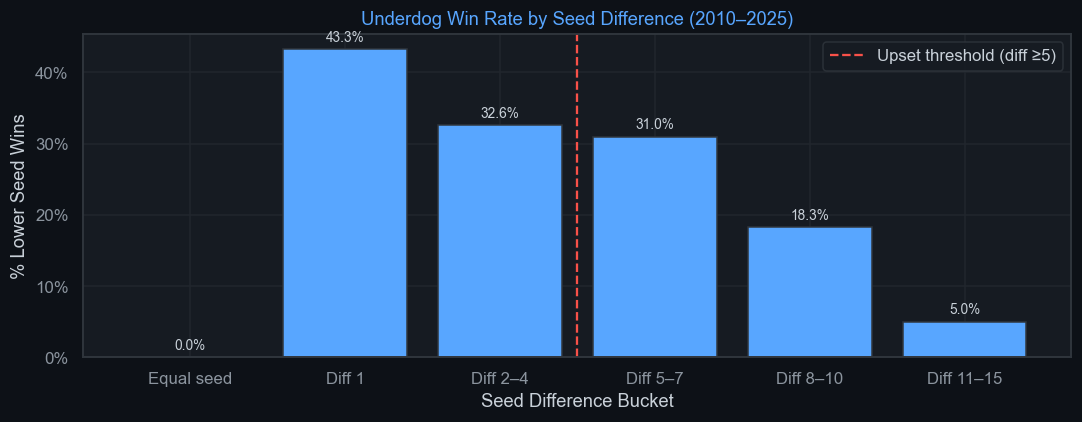

             games  lower_wins        pct
diff_bucket                              
Equal seed      96           0   0.000000
Diff 1         319         138  43.260188
Diff 2–4       386         126  32.642487
Diff 5–7       400         124  31.000000
Diff 8–10      338          62  18.343195
Diff 11–15     358          18   5.027933


In [15]:
bins   = [0, 1, 2, 4, 7, 10, 15]
labels = ['0 (even)', '1', '2–3', '4 (≤ threshold)', '5–7 (upset zone)', '8–10', '11–15']
# use actual seed_diff directly
df['diff_bucket'] = pd.cut(df.seed_diff, bins=[-0.5,0.5,1.5,4.5,7.5,10.5,15.5],
                            labels=['Equal seed','Diff 1','Diff 2–4','Diff 5–7','Diff 8–10','Diff 11–15'])

buck = df.groupby('diff_bucket', observed=True).agg(
    games=('lower_seed_won','count'),
    lower_wins=('lower_seed_won','sum'),
).assign(pct=lambda x: x.lower_wins/x.games*100)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')
bars = ax.bar(buck.index.astype(str), buck.pct, color='#58a6ff', edgecolor='#30363d')
ax.axvline(x=2.5, color='#f85149', linestyle='--', linewidth=1.5, label='Upset threshold (diff ≥5)')
ax.bar_label(bars, fmt='%.1f%%', color='#c9d1d9', fontsize=9, padding=3)
ax.set_xlabel('Seed Difference Bucket'); ax.set_ylabel('% Lower Seed Wins')
ax.set_title('Underdog Win Rate by Seed Difference (2010–2025)', color='#58a6ff', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(facecolor='#161b22', edgecolor='#30363d')
plt.tight_layout(); plt.show()
print(buck[['games','lower_wins','pct']].to_string())

## Upset rate heatmap: winning seed vs losing seed (R64, Men's)

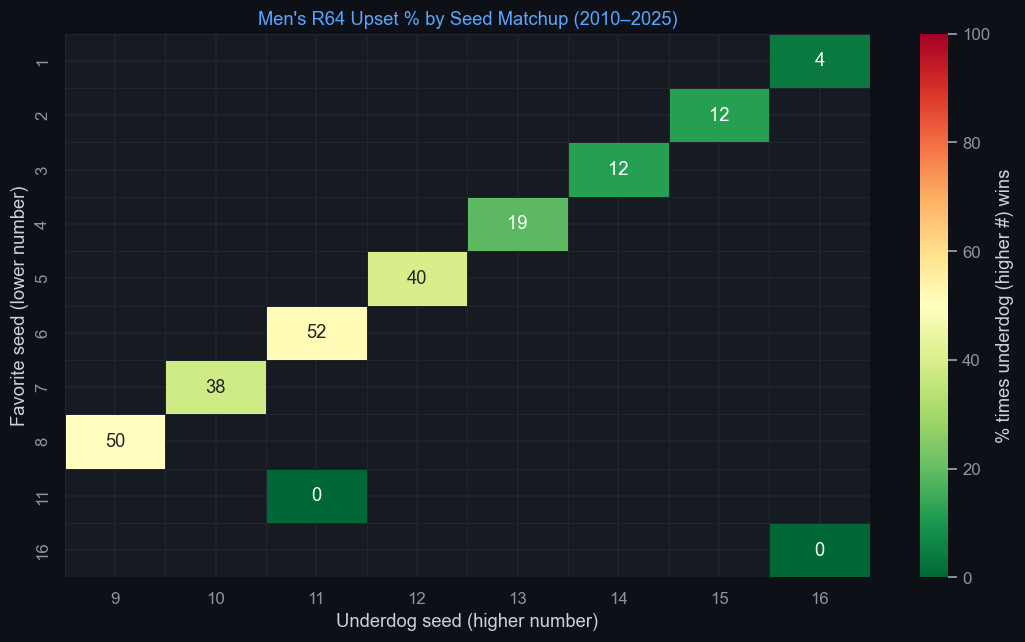

In [16]:
r64_m = df[(df.ROUND == 1) & (df.gender == 'Men')].copy()
r64_m['fav'] = r64_m[['W_SEED','L_SEED']].min(axis=1)
r64_m['dog'] = r64_m[['W_SEED','L_SEED']].max(axis=1)

piv = r64_m.groupby(['fav','dog'])['lower_seed_won'].mean().unstack(fill_value=np.nan) * 100

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(piv, annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': '% times underdog (higher #) wins'},
            linewidths=0.5, linecolor='#21262d', vmin=0, vmax=100)
ax.set_title("Men's R64 Upset % by Seed Matchup (2010–2025)", color='#58a6ff', fontsize=12)
ax.set_xlabel('Underdog seed (higher number)'); ax.set_ylabel('Favorite seed (lower number)')
plt.tight_layout(); plt.show()

## Per-round underdog win rate (bar, by gender)

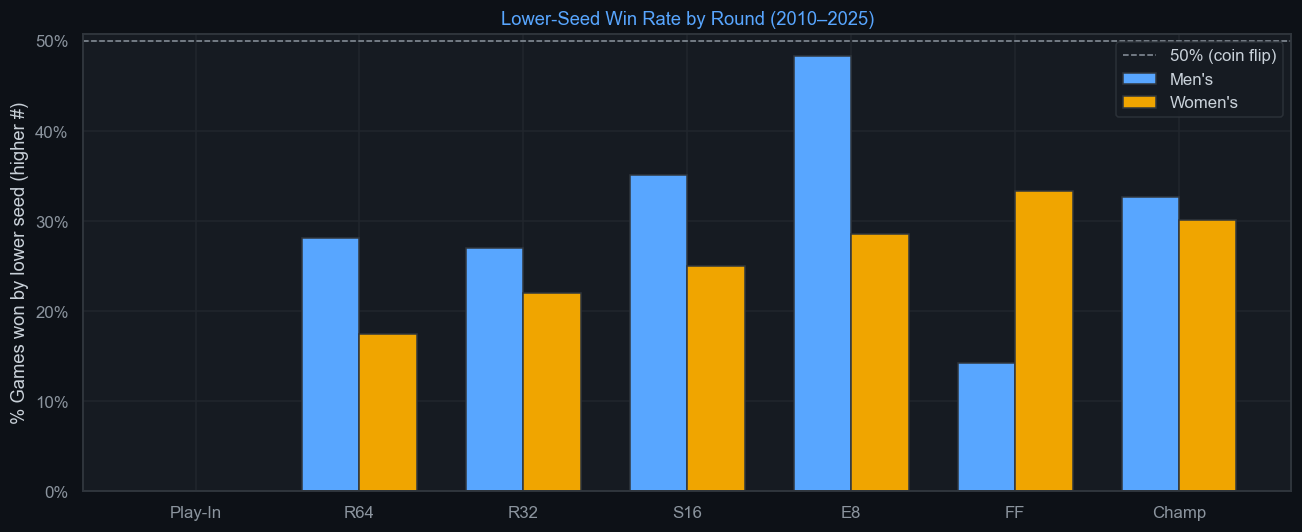

In [17]:
rg = df.groupby(['round_name','gender']).agg(
    games=('lower_seed_won','count'),
    underdog=('lower_seed_won','sum'),
).assign(pct=lambda x: x.underdog/x.games*100).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')

pivot = rg.pivot(index='round_name', columns='gender', values='pct').reindex(round_order).dropna(how='all')
x = np.arange(len(pivot))
w = 0.35
ax.bar(x - w/2, pivot['Men'],   w, label="Men's",   color='#58a6ff', edgecolor='#30363d')
ax.bar(x + w/2, pivot['Women'], w, label="Women's", color='#f0a500', edgecolor='#30363d')
ax.axhline(50, color='#8b949e', linestyle='--', linewidth=1, label='50% (coin flip)')

ax.set_xticks(x); ax.set_xticklabels(pivot.index)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_title('Lower-Seed Win Rate by Round (2010–2025)', color='#58a6ff', fontsize=12)
ax.set_ylabel('% Games won by lower seed (higher #)')
ax.legend(facecolor='#161b22', edgecolor='#30363d')
plt.tight_layout(); plt.show()

## Summary table

In [18]:
for label, subset in [('Overall (M+W)', df),
                       ("Men's only",  df[df.gender=='Men']),
                       ("Women's only", df[df.gender=='Women'])]:
    n        = len(subset)
    n_elig   = subset.upset_eligible.sum()
    n_upset  = subset.is_upset.sum()
    n_dog    = subset.lower_seed_won.sum()
    print(f"""
{'─'*52}
  {label}  (n={n:,})
{'─'*52}
  Upset-eligible games (seed diff ≥5):   {n_elig:>5} ({n_elig/n*100:.1f}%)
  Upsets (eligible & lower seed wins):    {n_upset:>5} ({n_upset/n*100:.1f}% of all | {n_upset/n_elig*100:.1f}% of eligible)
  Any underdog win  (lower seed # wins):  {n_dog:>5} ({n_dog/n*100:.1f}%)
""")


────────────────────────────────────────────────────
  Overall (M+W)  (n=1,897)
────────────────────────────────────────────────────
  Upset-eligible games (seed diff ≥5):    1096 (57.8%)
  Upsets (eligible & lower seed wins):      204 (10.8% of all | 18.6% of eligible)
  Any underdog win  (lower seed # wins):    468 (24.7%)


────────────────────────────────────────────────────
  Men's only  (n=988)
────────────────────────────────────────────────────
  Upset-eligible games (seed diff ≥5):     583 (59.0%)
  Upsets (eligible & lower seed wins):      143 (14.5% of all | 24.5% of eligible)
  Any underdog win  (lower seed # wins):    273 (27.6%)


────────────────────────────────────────────────────
  Women's only  (n=909)
────────────────────────────────────────────────────
  Upset-eligible games (seed diff ≥5):     513 (56.4%)
  Upsets (eligible & lower seed wins):       61 (6.7% of all | 11.9% of eligible)
  Any underdog win  (lower seed # wins):    195 (21.5%)

